In [28]:
import pandas as pd

In [29]:
df=pd.read_csv('messy_employee_data.csv')
df.head()

,EmployeeID,FirstName,LastName,Age,Gender,City,Department,Salary,JoinDate,Email,PerformanceRating
0,12,William,Moore,45.0,F,Chicago,Sales,60000.5,2022-07-19,william.moore@example.com,1
1,130,David,Williams,29.0,Male,Miami,Sales,52000.0,2021-05-01,david.williams@example.com,5 stars
2,141,Sarah,Johnson,40.0,Male,Miami,Marketing,88000.0,15-03-2022,sarah.johnson@example.com,10
3,157,Anna,Jones,35.0,M,Miami,Finance,60000.5,01/06/2020,anna.jones@example.com,3.5
4,103,Emily,Wilson,-5.0,Female,chicago,Finance,73000.0,15-03-2022,emily.wilson@example.com,4


In [30]:
df.shape
df.info()
df.describe()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         209 non-null    int64  
 1   FirstName          209 non-null    str    
 2   LastName           209 non-null    str    
 3   Age                193 non-null    float64
 4   Gender             178 non-null    str    
 5   City               177 non-null    str    
 6   Department         183 non-null    str    
 7   Salary             168 non-null    float64
 8   JoinDate           180 non-null    str    
 9   Email              201 non-null    str    
 10  PerformanceRating  187 non-null    str    
dtypes: float64(2), int64(1), str(8)
memory usage: 18.1 KB


EmployeeID             int64
FirstName                str
LastName                 str
Age                  float64
Gender                   str
City                     str
Department               str
Salary               float64
JoinDate                 str
Email                    str
PerformanceRating        str
dtype: object

In [31]:
df.isnull().sum()

EmployeeID            0
FirstName             0
LastName              0
Age                  16
Gender               31
City                 32
Department           26
Salary               41
JoinDate             29
Email                 8
PerformanceRating    22
dtype: int64

In [32]:
df[df.duplicated()]
df.drop_duplicates(inplace=True)

In [33]:
df['FirstName'] = df['FirstName'].str.title()
df['LastName'] = df['LastName'].str.title()
df['City'] = df['City'].str.title()
df['Department'] = df['Department'].str.title()
df

,EmployeeID,FirstName,LastName,Age,Gender,City,Department,Salary,JoinDate,Email,PerformanceRating
0,12,William,Moore,45.0,F,Chicago,Sales,60000.5,2022-07-19,william.moore@example.com,1
1,130,David,Williams,29.0,Male,Miami,Sales,52000.0,2021-05-01,david.williams@example.com,5 stars
2,141,Sarah,Johnson,40.0,Male,Miami,Marketing,88000.0,15-03-2022,sarah.johnson@example.com,10
3,157,Anna,Jones,35.0,M,Miami,Finance,60000.5,01/06/2020,anna.jones@example.com,3.5
4,103,Emily,Wilson,-5.0,Female,Chicago,Finance,73000.0,15-03-2022,emily.wilson@example.com,4
...,...,...,...,...,...,...,...,...,...,...,...
204,152,Mike,Moore,50.0,Male,Boston,Marketing,NaN,01/06/2020,mike.moore@example.com,NaN
205,68,Lisa,Moore,28.0,M,Boston,Sales,88000.0,01/06/2020,lisa.moore@example.com,5
206,26,Sarah,Johnson,50.0,M,Miami,Sales,60000.5,2021-05-01,sarah.johnson@example.com,4
207,197,Mary,Williams,40.0,F,Miami,Marketing,73000.0,2019/11/23,mary.williams@example.com,3.5


In [34]:

df['Gender'] = df['Gender'].str.lower()
df.replace({'Gender': {'f': 'female', 'm': 'male'}}, inplace=True)
df['Gender']=df['Gender'].str.title()
df['Gender'].unique()

<StringArray>
['Female', 'Male', nan]
Length: 3, dtype: str

In [40]:

df.replace({'City': {'L.A.': 'Los Angeles'}}, inplace=True)
df['Department'].unique()

<StringArray>
['Sales ', 'Marketing', 'Finance', nan, 'It', 'Sales', 'Hr']
Length: 7, dtype: str

In [36]:
df['Salary']=pd.to_numeric(df['Salary'], errors='coerce')
df['JoinDate'] = pd.to_numeric(df['JoinDate'], errors='coerce')

In [48]:

sal=df['Salary'].median()
df['Salary']=df['Salary'].fillna(sal)
ag = df['Age'].median()
df['Age'] = df['Age'].fillna(ag)
df['Salary'].unique()
df['Age'].unique()

array([ 45.,  29.,  40.,  35.,  -5., 150.,  50.,  28.,  31.,  22.,  25.])

In [53]:
df.loc[(df['Age']<0) | (df['Age']>100),'Age']=float('nan')
df['Age']=df['Age'].fillna(df['Age'].median())
df.loc[df['Salary'] < 0, 'Salary'] = float('nan')
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [56]:
df['Salary'].unique()
df

,EmployeeID,FirstName,LastName,Age,Gender,City,Department,Salary,JoinDate,Email,PerformanceRating
0,12,William,Moore,45.0,Female,Chicago,Sales,60000.5,NaN,william.moore@example.com,1
1,130,David,Williams,29.0,Male,Miami,Sales,52000.0,NaN,david.williams@example.com,5 stars
2,141,Sarah,Johnson,40.0,Male,Miami,Marketing,88000.0,NaN,sarah.johnson@example.com,10
3,157,Anna,Jones,35.0,Male,Miami,Finance,60000.5,NaN,anna.jones@example.com,3.5
4,103,Emily,Wilson,31.0,Female,Chicago,Finance,73000.0,NaN,emily.wilson@example.com,4
...,...,...,...,...,...,...,...,...,...,...,...
204,152,Mike,Moore,50.0,Male,Boston,Marketing,61000.0,NaN,mike.moore@example.com,NaN
205,68,Lisa,Moore,28.0,Male,Boston,Sales,88000.0,NaN,lisa.moore@example.com,5
206,26,Sarah,Johnson,50.0,Male,Miami,Sales,60000.5,NaN,sarah.johnson@example.com,4
207,197,Mary,Williams,40.0,Female,Miami,Marketing,73000.0,NaN,mary.williams@example.com,3.5


In [58]:
df['Age']=df['Age'].astype(int)
df['Salary'] = df['Salary'].astype(int)
df.dtypes

EmployeeID             int64
FirstName                str
LastName                 str
Age                    int64
Gender                   str
City                     str
Department               str
Salary                 int64
JoinDate             float64
Email                    str
PerformanceRating        str
dtype: object

In [67]:
import re
df['PerformanceRating'].unique()


def extract_age(PerformanceRating):
    age_num = re.findall('[0-9]+', str(PerformanceRating))
    if len(age_num) > 0:
        return age_num[0]
    else:
        return PerformanceRating

df['PerformanceRating'] = df['PerformanceRating'].apply(lambda x: extract_age(x))

df['PerformanceRating'] = pd.to_numeric(df['PerformanceRating'], errors='coerce')
df.loc[df['PerformanceRating']>5,'PerformanceRating']=float('nan')
df['PerformanceRating'] = df['PerformanceRating'].fillna(
    df['PerformanceRating'].median())

df['PerformanceRating'].unique()
df

,EmployeeID,FirstName,LastName,Age,Gender,City,Department,Salary,JoinDate,Email,PerformanceRating
0,12,William,Moore,45,Female,Chicago,Sales,60000,NaN,william.moore@example.com,1.0
1,130,David,Williams,29,Male,Miami,Sales,52000,NaN,david.williams@example.com,5.0
2,141,Sarah,Johnson,40,Male,Miami,Marketing,88000,NaN,sarah.johnson@example.com,3.0
3,157,Anna,Jones,35,Male,Miami,Finance,60000,NaN,anna.jones@example.com,3.0
4,103,Emily,Wilson,31,Female,Chicago,Finance,73000,NaN,emily.wilson@example.com,4.0
...,...,...,...,...,...,...,...,...,...,...,...
204,152,Mike,Moore,50,Male,Boston,Marketing,61000,NaN,mike.moore@example.com,3.0
205,68,Lisa,Moore,28,Male,Boston,Sales,88000,NaN,lisa.moore@example.com,5.0
206,26,Sarah,Johnson,50,Male,Miami,Sales,60000,NaN,sarah.johnson@example.com,4.0
207,197,Mary,Williams,40,Female,Miami,Marketing,73000,NaN,mary.williams@example.com,3.0


In [85]:
df.info()
df['Gender']=df['Gender'].fillna(df['Gender'].mode())
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 201 entries, 0 to 208
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         201 non-null    int64  
 1   FirstName          201 non-null    str    
 2   LastName           201 non-null    str    
 3   Age                201 non-null    int64  
 4   Gender             172 non-null    str    
 5   City               170 non-null    str    
 6   Department         176 non-null    str    
 7   Salary             201 non-null    int64  
 8   Email              193 non-null    str    
 9   PerformanceRating  201 non-null    float64
dtypes: float64(1), int64(3), str(6)
memory usage: 17.3 KB


EmployeeID            0
FirstName             0
LastName              0
Age                   0
Gender               29
City                 31
Department           25
Salary                0
Email                 8
PerformanceRating     0
dtype: int64

In [93]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [95]:
df.isnull().sum()

EmployeeID           0
FirstName            0
LastName             0
Age                  0
Gender               0
City                 0
Department           0
Salary               0
Email                8
PerformanceRating    0
dtype: int64

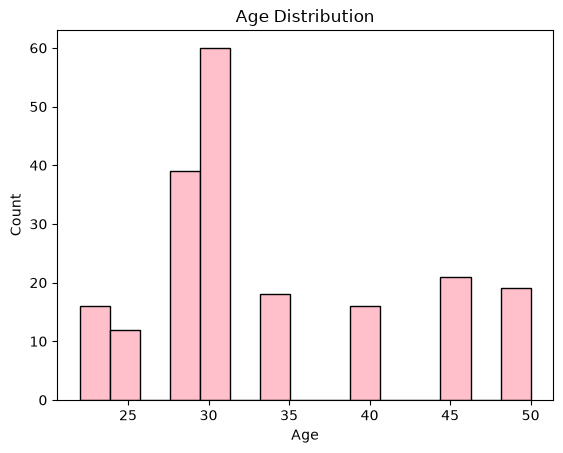

In [106]:
import matplotlib as mb
import matplotlib.pyplot as plt

plt.hist(df['Age'].dropna(), bins=15, edgecolor='black', facecolor='pink')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

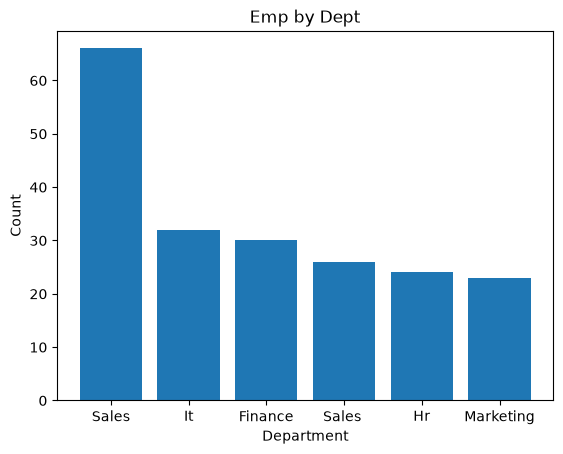

In [ ]:
plt.bar(df['Department'].value_counts().index, df['Department'].value_counts().values)
plt.title('Emp by Dept')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

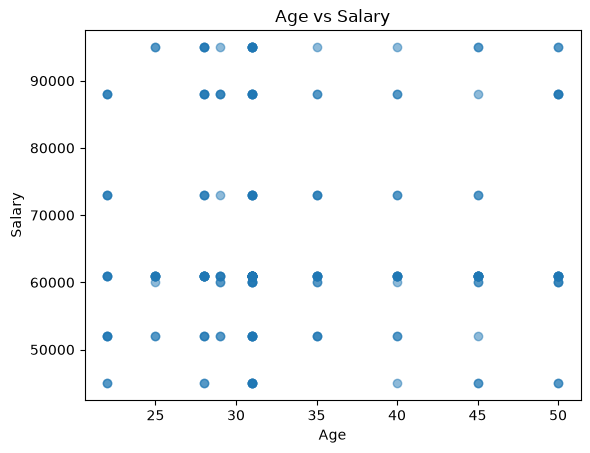

In [108]:
plt.scatter(df['Age'], df['Salary'], alpha=0.5)
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()